# 04 — Predictive Model & Distribution Drift Monitoring

**Goal:** Train a baseline Ridge regression to predict next-day SPY log returns and then monitor its performance as the return distribution shifts over time.

---

### Question
> *Does statistical distribution drift (measured by PSI, KL divergence, and the KS test) predict degradation in model performance (RMSE, directional accuracy)?*

### Pipeline
```
Raw returns
  └─► Feature matrix (notebook 02)
        └─► Walk-forward backtest -> predictions
              └─► Rolling RMSE  ─┐
                                 ├─► Drift-performance correlation
              PSI / KS / KL   ───┘
```

### Note
A **walk-forward** (rolling window) design is used to prevent look-ahead bias:
- Train on 252 days, test on the next 63 days and advance by 21 days.
- The scaler is fit **only** on the training slice at each fold.

In [ ]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr

from preprocessing import preprocess_pipeline
from features import build_feature_matrix, add_lagged_returns
from regime_detector import HMMRegimeDetector
from model import (
    walk_forward_backtest,
    predictions_to_dataframe,
    get_full_prediction_series,
    feature_importance_over_time,
)
from evaluation import (
    drift_performance_correlation,
    print_correlation_summary,
    plot_monitoring_dashboard,
    rolling_prediction_metrics,
    regime_performance_table,
    plot_regime_performance_bar,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

# Load data and compute log returns 
data        = preprocess_pipeline()
prices      = data['prices']
log_returns = data['log_returns']

print(f'Loaded {len(log_returns):,} log returns  ({log_returns.index[0].date()} → {log_returns.index[-1].date()})')

Loaded 5,336 log returns  (2005-01-04 → 2026-03-20)


---
## 1. Feature Engineering

Build the feature matrix and construct the prediction target (next-day return).

In [2]:
# Feature matrix
features = build_feature_matrix(
    log_returns,
    windows=[20, 60, 252],
    include_vov=True,
    include_autocorr=False,   # skip autocorr for speed
)
features = add_lagged_returns(features, log_returns, lags=[1, 2, 3, 5])

# Target: next-day log return
# Shift returns backward by 1 so that feature row t predicts return at t+1.
target = log_returns.shift(-1).rename('next_day_return')

# Align and clean
aligned = pd.concat([features, target], axis=1).dropna()
X = aligned.drop(columns='next_day_return')
y = aligned['next_day_return']

print(f'Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Target         : {y.shape[0]:,} samples')
print(f'Date range     : {X.index[0].date()} → {X.index[-1].date()}')

Feature matrix : 5,084 rows × 26 features
Target         : 5,084 samples
Date range     : 2006-01-03 → 2026-03-19


---
## 2. Walk-Forward Backtest

Train=252 days (1 year), Test=63 days (1 quarter), Step=21 days (1 month).

In [3]:
print('Running walk-forward backtest...')

records = walk_forward_backtest(
    features=X,
    target=y,
    train_window=252,
    test_window=63,
    step=21,
    alpha=1.0,
)

print(f'Folds completed: {len(records)}')
print(f'First fold test: {records[0].test_start.date()} → {records[0].test_end.date()}')
print(f'Last  fold test: {records[-1].test_start.date()} → {records[-1].test_end.date()}')

Running walk-forward backtest...
Folds completed: 228
First fold test: 2007-01-04 → 2007-04-04
Last  fold test: 2025-12-15 → 2026-03-17


In [5]:
# Aggregate fold-level metrics
fold_metrics = predictions_to_dataframe(records)

print('\n Overall Model Performance (all folds)')
overall = fold_metrics[['rmse', 'mae', 'r2', 'directional_accuracy']].describe()
print(overall.round(5).to_string())

print(f'\nMean RMSE              : {fold_metrics["rmse"].mean():.5f}')
print(f'Mean Directional Acc.  : {fold_metrics["directional_accuracy"].mean():.3f}  '
      f'(random baseline = 0.50)')


 Overall Model Performance (all folds)
            rmse        mae         r2  directional_accuracy
count  228.00000  228.00000  228.00000             228.00000
mean     0.01843    0.01510   -6.21412               0.48977
std      0.01690    0.01547   37.00343               0.07400
min      0.00457    0.00301 -531.01180               0.30159
25%      0.00985    0.00771   -2.18226               0.42857
50%      0.01348    0.01037   -0.92035               0.49206
75%      0.02015    0.01633   -0.42946               0.53968
max      0.16570    0.16354    0.06830               0.66667

Mean RMSE              : 0.01843
Mean Directional Acc.  : 0.490  (random baseline = 0.50)


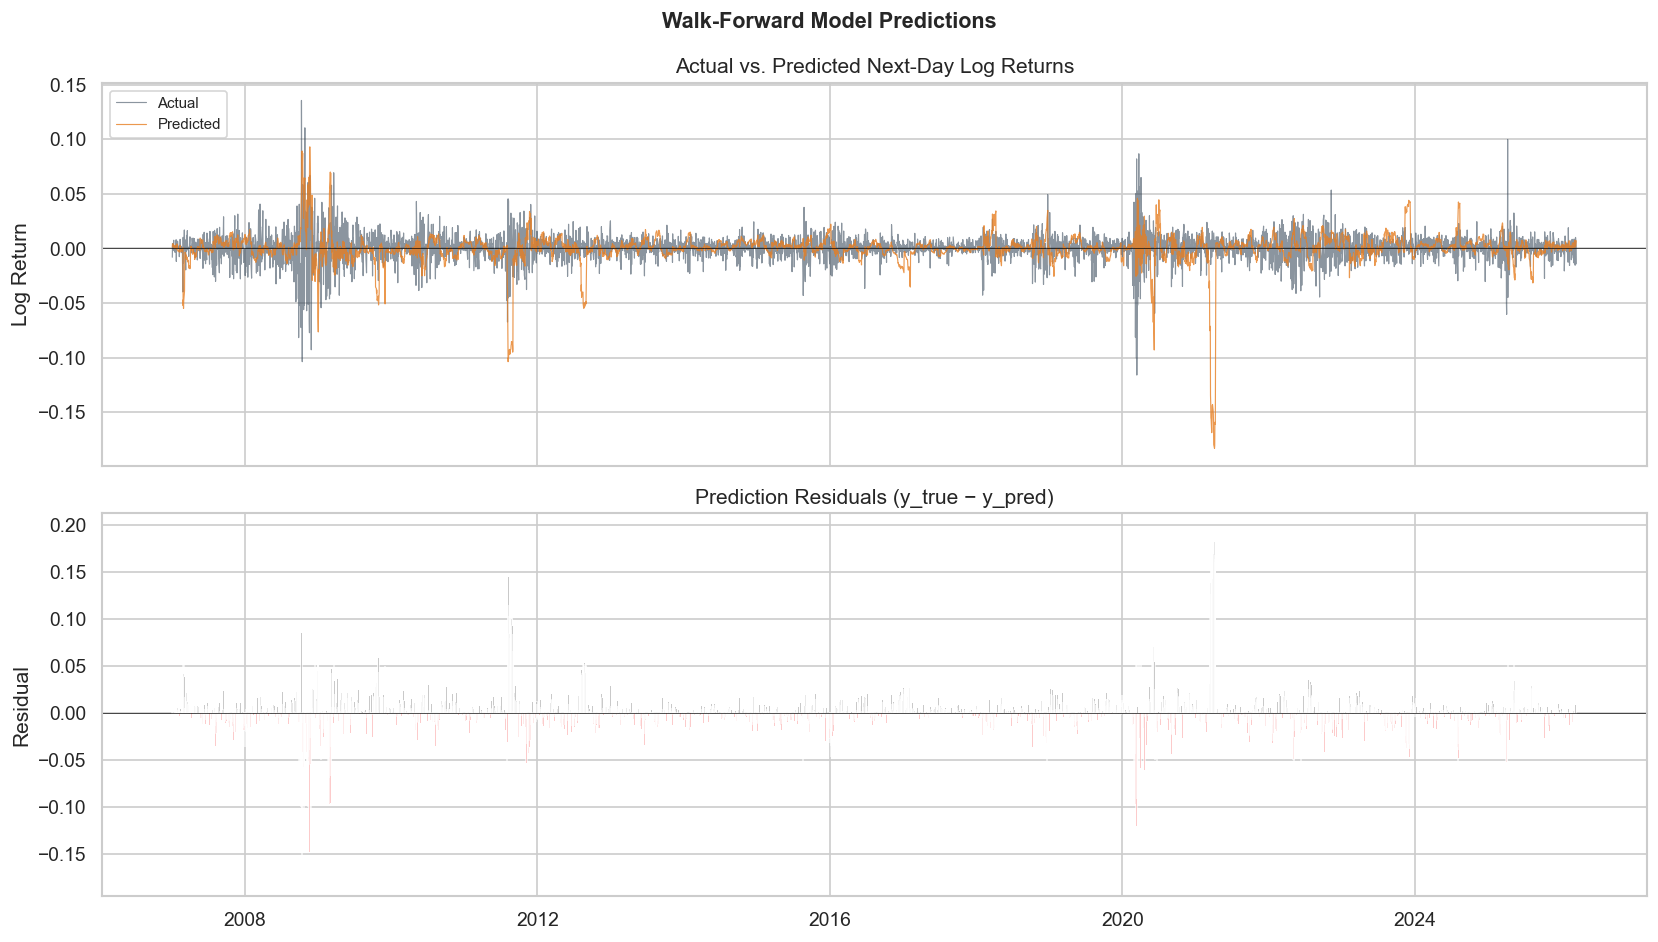

In [9]:
# Reconstruct continuous prediction series
pred_df = get_full_prediction_series(records, X.index)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(pred_df.index, pred_df['y_true'],
             color='#2c3e50', alpha=0.55, linewidth=0.7, label='Actual')
axes[0].plot(pred_df.index, pred_df['y_pred'],
             color='#e67e22', alpha=0.80, linewidth=0.7, label='Predicted')
axes[0].set_title('Actual vs. Predicted Next-Day Log Returns')
axes[0].set_ylabel('Log Return')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.4)

residuals = pred_df['y_true'] - pred_df['y_pred']
axes[1].bar(residuals.index, residuals.values,
            color=np.where(residuals.values >= 0, "#000000", "#f40808ff"),
            width=1, alpha=0.7)
axes[1].set_title('Prediction Residuals (y_true − y_pred)')
axes[1].set_ylabel('Residual')
axes[1].axhline(0, color='black', linewidth=0.4)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Walk-Forward Model Predictions', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 3. Rolling Model Performance

RMSE and directional accuracy computed on a 63-day (1-quarter) rolling window.  
Spikes in RMSE and drops in directional accuracy indicate periods of model degradation.

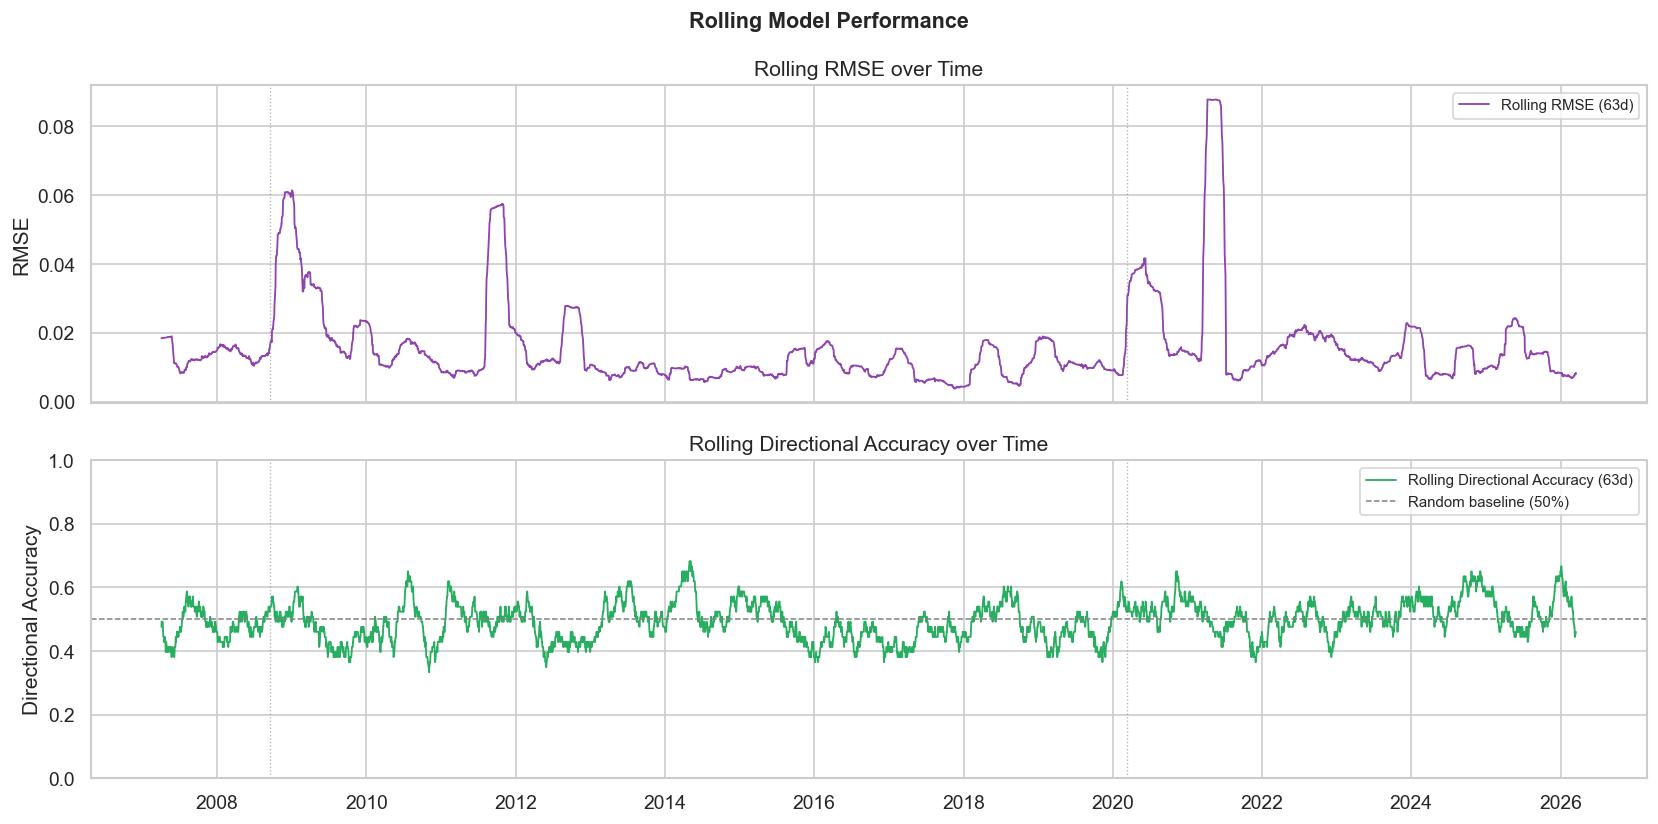

In [10]:
perf_df = rolling_prediction_metrics(pred_df, window=63)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(perf_df.index, perf_df['rolling_rmse'],
             color='#8e44ad', linewidth=1.1, label='Rolling RMSE (63d)')
axes[0].set_title('Rolling RMSE over Time')
axes[0].set_ylabel('RMSE')
axes[0].legend(fontsize=9)

axes[1].plot(perf_df.index, perf_df['rolling_dir_acc'],
             color='#27ae60', linewidth=1.1, label='Rolling Directional Accuracy (63d)')
axes[1].axhline(0.50, color='grey', linestyle='--', linewidth=0.9, label='Random baseline (50%)')
axes[1].set_title('Rolling Directional Accuracy over Time')
axes[1].set_ylabel('Directional Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotate key crisis events
for ax in axes:
    for dt, label in [('2008-09-15', 'GFC'), ('2020-03-11', 'COVID')]:
        ax.axvline(pd.Timestamp(dt), color='grey', linestyle=':', alpha=0.6, linewidth=0.8)

fig.suptitle('Rolling Model Performance', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 4. Distribution Drift Metrics

Compute PSI, KL divergence, and rolling KS test on the same time axis as model performance.

In [11]:
from rolling_stats import compute_rolling_drift, rolling_ks_test

drift_df = compute_rolling_drift(log_returns, ref_window=252, step=21)
ks_df    = rolling_ks_test(log_returns, ref_window=252, test_window=63)

print(f'PSI series  : {len(drift_df):,} observations')
print(f'KS series   : {len(ks_df):,} observations')
print(f'\nPSI > 0.20 (severe drift): {(drift_df["psi"] > 0.20).sum():,} months '
      f'({100*(drift_df["psi"]>0.20).mean():.1f}%)')
print(f'KS p<0.05 (sig. drift)  : {ks_df["drift_flag"].sum():,} days '
      f'({100*ks_df["drift_flag"].mean():.1f}%)')

PSI series  : 240 observations
KS series   : 5,021 observations

PSI > 0.20 (severe drift): 173 months (72.1%)
KS p<0.05 (sig. drift)  : 1,024 days (20.4%)


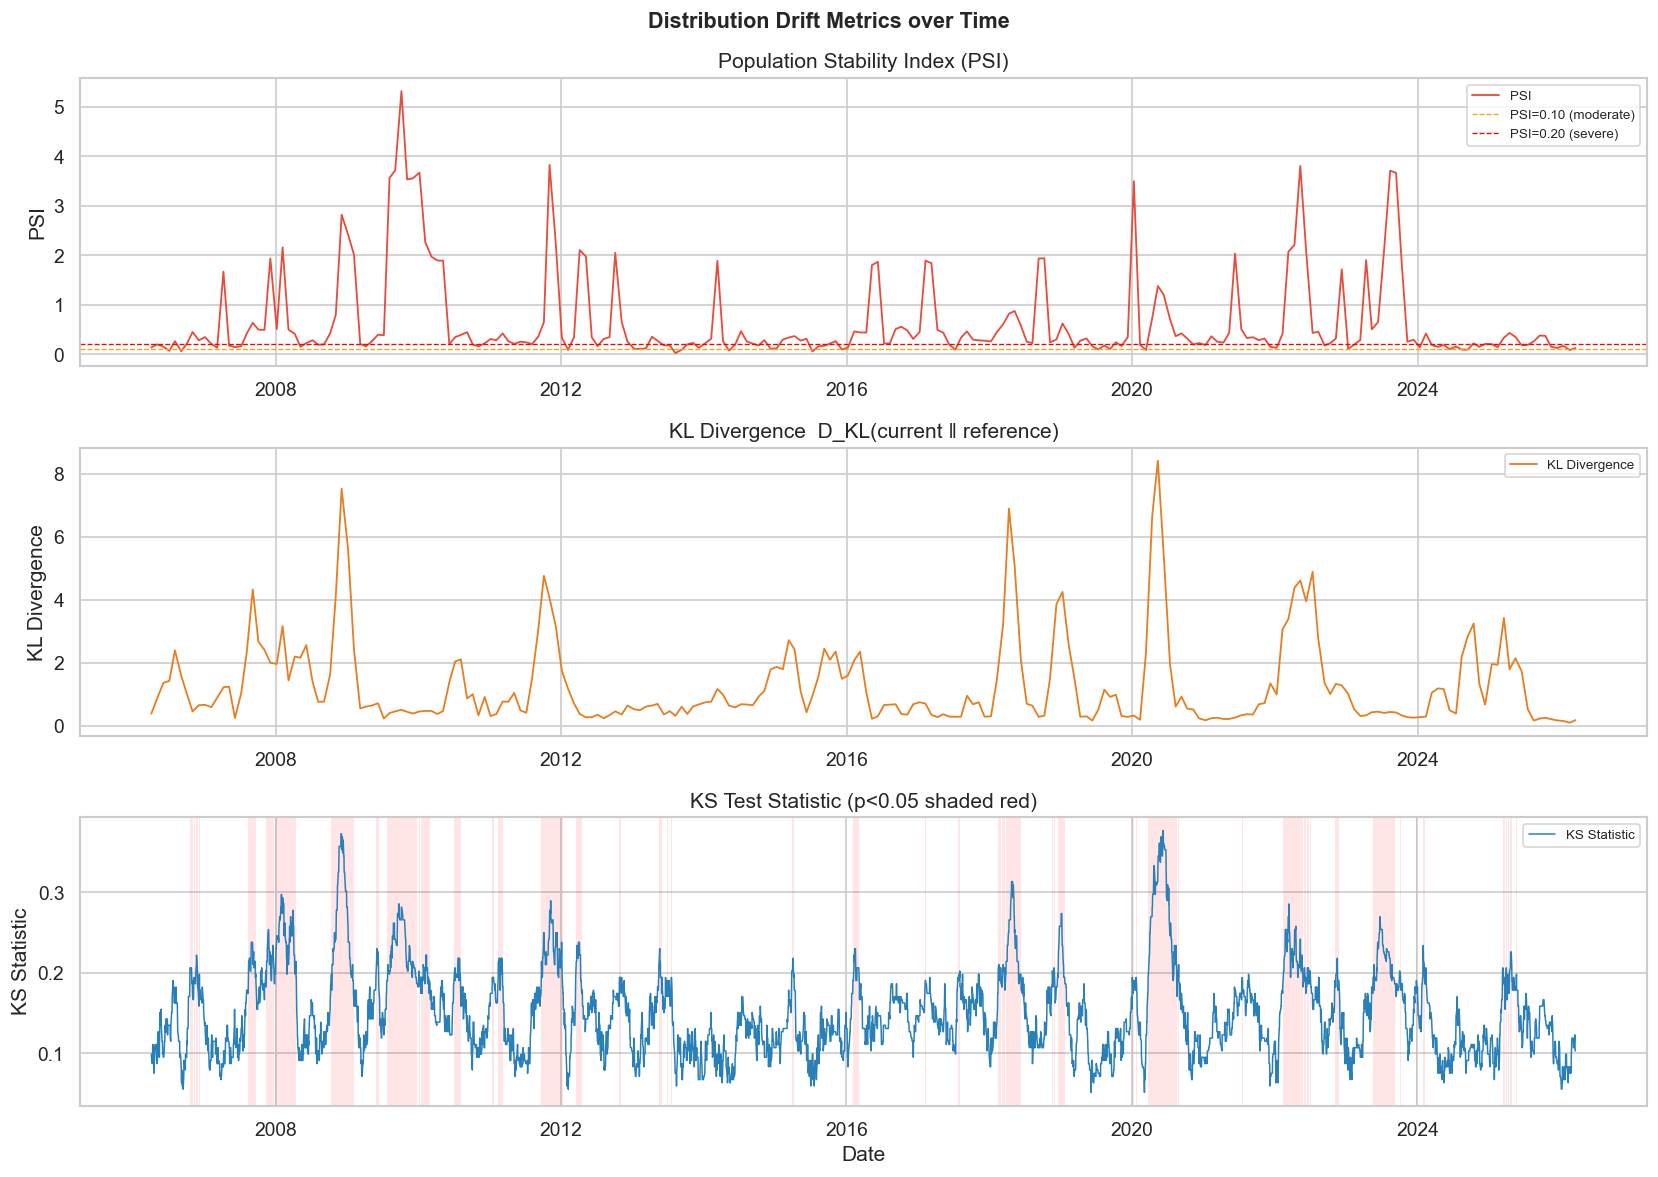

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# PSI
axes[0].plot(drift_df.index, drift_df['psi'], color='#e74c3c', linewidth=1.1, label='PSI')
axes[0].axhline(0.10, color='orange', linestyle='--', linewidth=0.8, label='PSI=0.10 (moderate)')
axes[0].axhline(0.20, color='red',    linestyle='--', linewidth=0.8, label='PSI=0.20 (severe)')
axes[0].set_title('Population Stability Index (PSI)')
axes[0].set_ylabel('PSI')
axes[0].legend(fontsize=8)

# KL Divergence
axes[1].plot(drift_df.index, drift_df['kl_div'], color='#e67e22', linewidth=1.1, label='KL Divergence')
axes[1].set_title('KL Divergence  D_KL(current ‖ reference)')
axes[1].set_ylabel('KL Divergence')
axes[1].legend(fontsize=8)

# KS statistic
axes[2].plot(ks_df.index, ks_df['ks_stat'], color='#2980b9', linewidth=0.9, label='KS Statistic')
in_drift = False
drift_start = None
for date, flag in ks_df['drift_flag'].items():
    if flag and not in_drift:
        drift_start = date; in_drift = True
    elif not flag and in_drift:
        axes[2].axvspan(drift_start, date, color='red', alpha=0.10, lw=0)
        in_drift = False
if in_drift:
    axes[2].axvspan(drift_start, ks_df.index[-1], color='red', alpha=0.10, lw=0)
axes[2].set_title('KS Test Statistic (p<0.05 shaded red)')
axes[2].set_ylabel('KS Statistic')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Distribution Drift Metrics over Time', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 5. Drift–Performance Correlation

The central question: **does distribution drift predict model degradation?**

We test this by correlating each drift metric (PSI, KL div, KS statistic) with each performance metric (rolling RMSE, directional accuracy).

In [13]:
merged = drift_performance_correlation(log_returns, pred_df, drift_window=252)
print_correlation_summary(merged)


── Drift → Performance Correlation (Pearson r) ──────────────────────
  psi        vs rolling_rmse          : r = +0.225  p = 0.0007  ***
  psi        vs rolling_dir_acc       : r = -0.172  p = 0.0096  **
  kl_div     vs rolling_rmse          : r = +0.376  p = 0.0000  ***
  kl_div     vs rolling_dir_acc       : r = +0.157  p = 0.0182  *
  ks_stat    vs rolling_rmse          : r = +0.381  p = 0.0000  ***
  ks_stat    vs rolling_dir_acc       : r = -0.052  p = 0.4344  



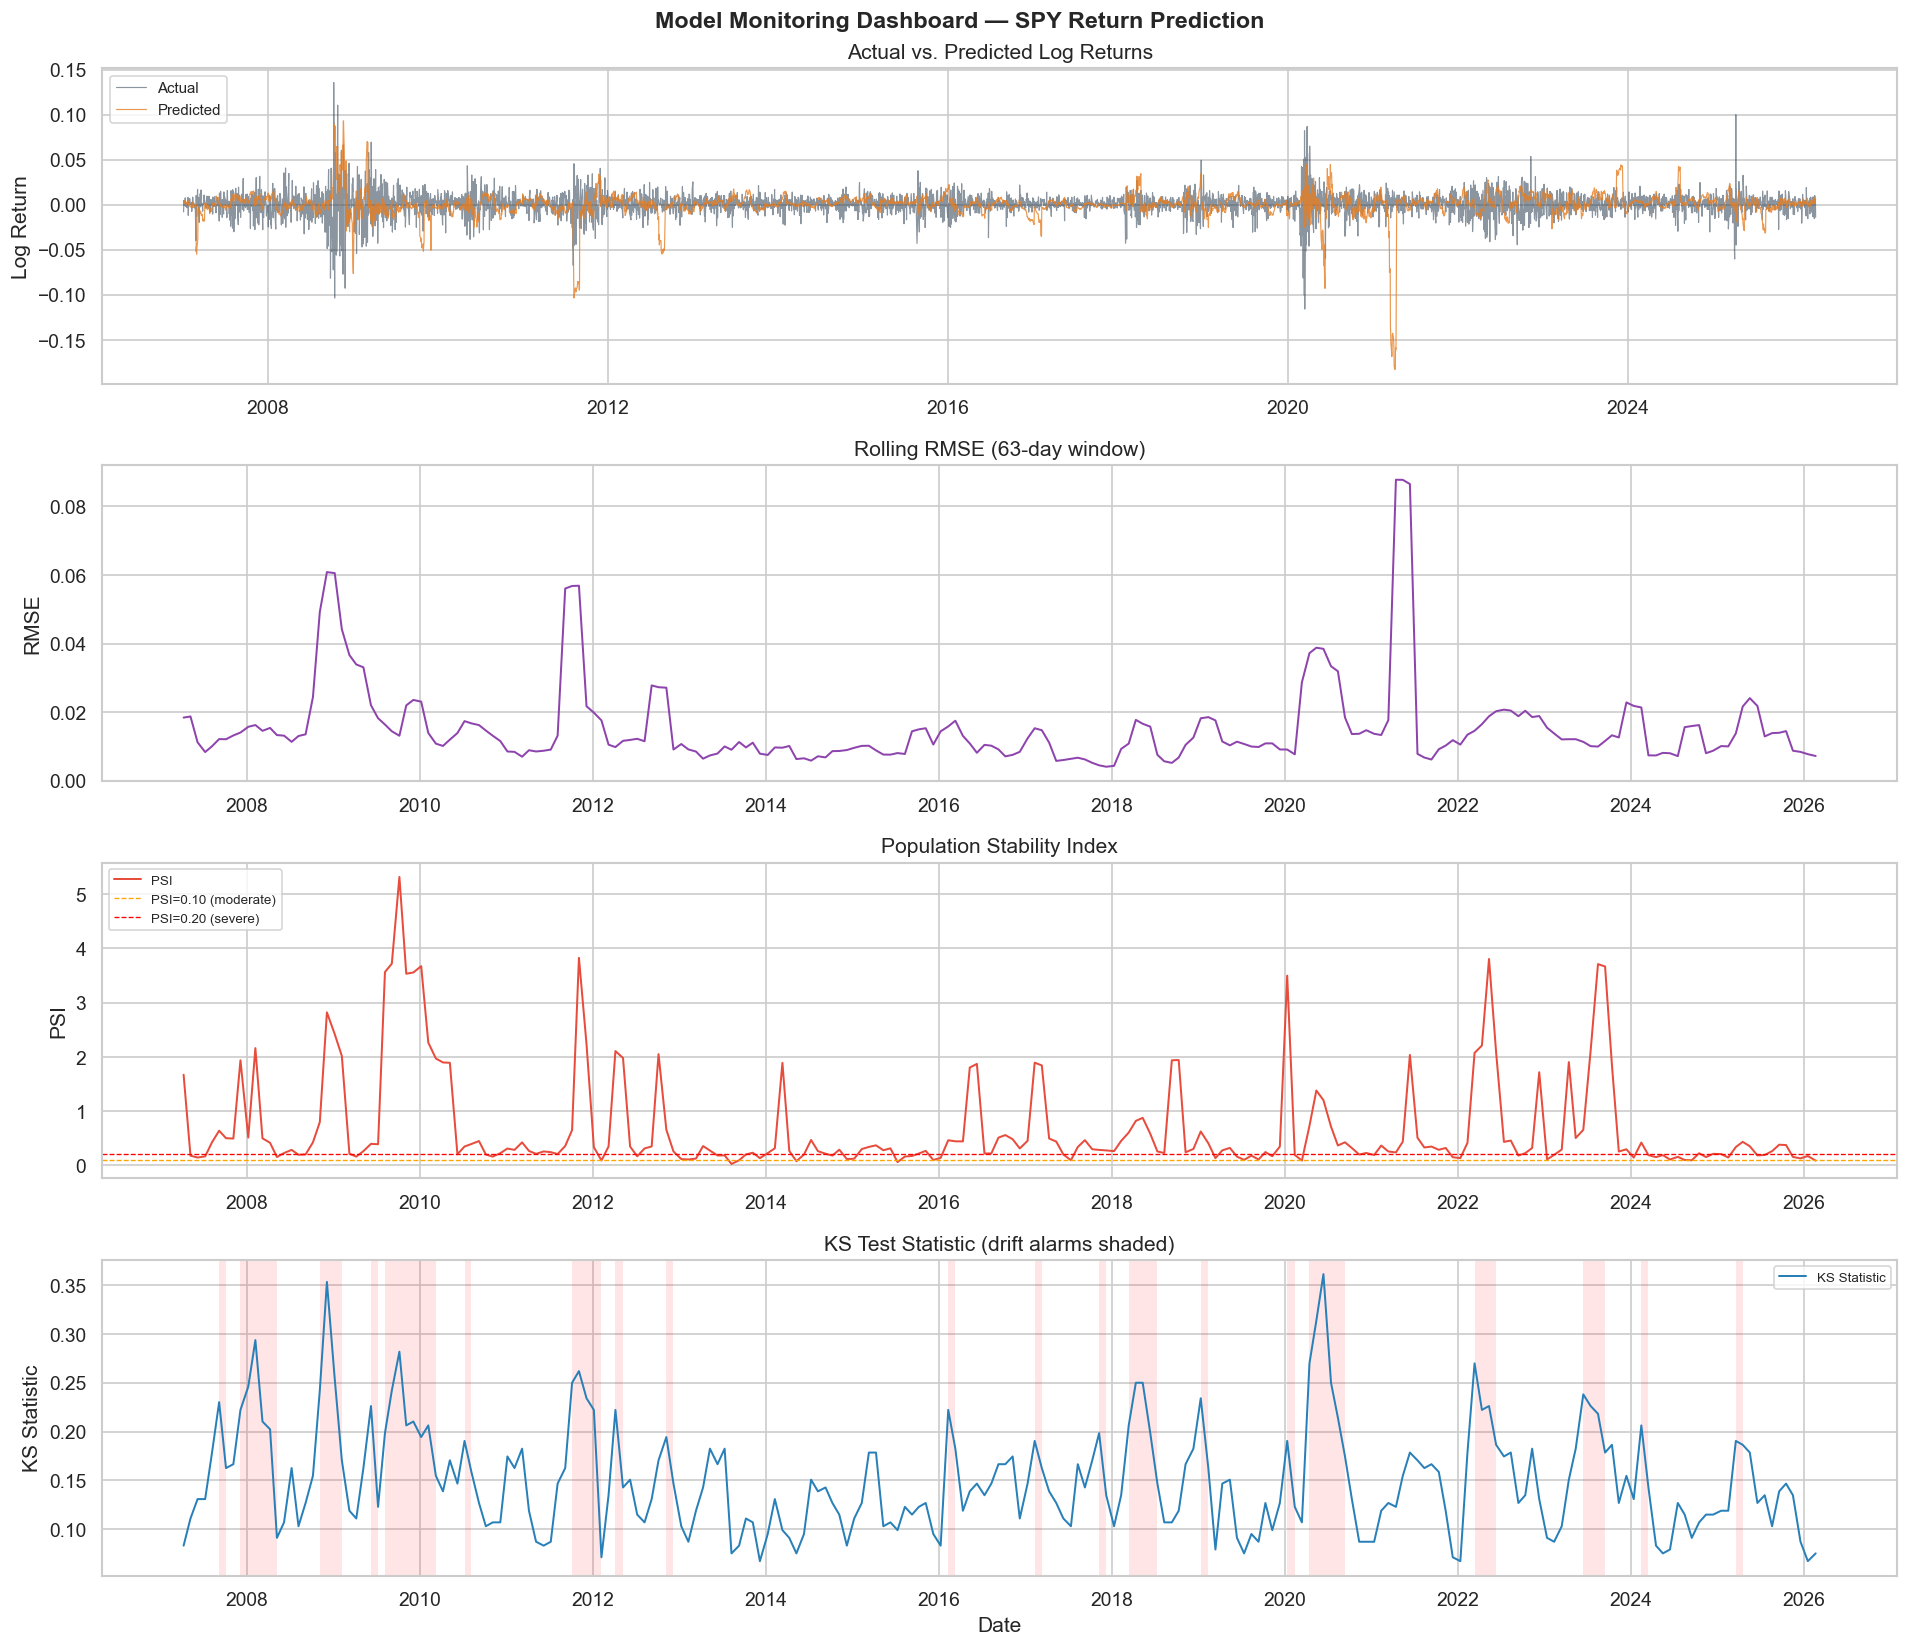

In [14]:
# Full monitoring dashboard
fig = plot_monitoring_dashboard(pred_df, merged, figsize=(16, 14))
plt.show()

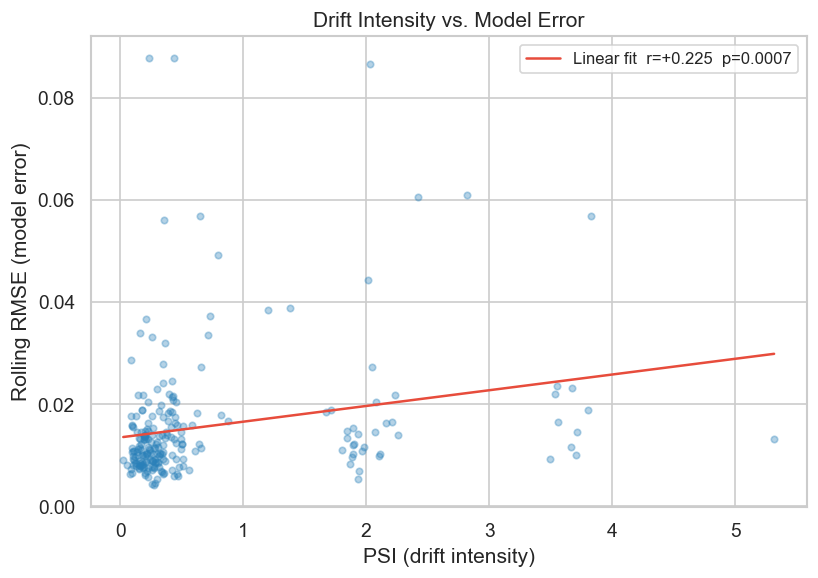

Pearson r = +0.2245  (p = 0.0007)
→ Statistically significant positive correlation: distribution drift predicts model error.


In [15]:
# Scatter: PSI vs Rolling RMSE
common_idx = merged.dropna(subset=['psi', 'rolling_rmse']).index
psi_vals  = merged.loc[common_idx, 'psi']
rmse_vals = merged.loc[common_idx, 'rolling_rmse']

r, p = pearsonr(psi_vals, rmse_vals)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(psi_vals, rmse_vals, alpha=0.35, s=15, color='#2980b9')

# Regression line
m, b = np.polyfit(psi_vals, rmse_vals, 1)
x_line = np.linspace(psi_vals.min(), psi_vals.max(), 100)
ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=1.5,
        label=f'Linear fit  r={r:+.3f}  p={p:.4f}')

ax.set_xlabel('PSI (drift intensity)')
ax.set_ylabel('Rolling RMSE (model error)')
ax.set_title('Drift Intensity vs. Model Error')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

print(f'Pearson r = {r:+.4f}  (p = {p:.4f})')
if p < 0.05:
    direction = 'positive' if r > 0 else 'negative'
    print(f'→ Statistically significant {direction} correlation: distribution drift {'predicts' if r>0 else 'inversely relates to'} model error.')
else:
    print('→ No statistically significant correlation between PSI and RMSE at α=0.05.')

---
## 6. Regime-Stratified Performance

How does model performance differ **within** each HMM-detected regime?

In [17]:
# Fit HMM regimes on the full return series
hmm = HMMRegimeDetector(n_regimes=2, random_state=42)
hmm_regimes = hmm.fit_predict(log_returns)

# Compute per-regime performance metrics
regime_perf = regime_performance_table(pred_df, hmm_regimes)
print('\n Model Performance by HMM Regime')
print(regime_perf.round(4).to_string())

Model is not converging.  Current: 17307.59970979427 is not greater than 17307.61998313988. Delta is -0.020273345609894022



 Model Performance by HMM Regime
                   rmse     mae      r2  directional_accuracy  n_days
regime                                                               
low_volatility   0.0159  0.0087 -3.5777                0.4885    3648
high_volatility  0.0294  0.0203 -0.8846                0.5127    1182


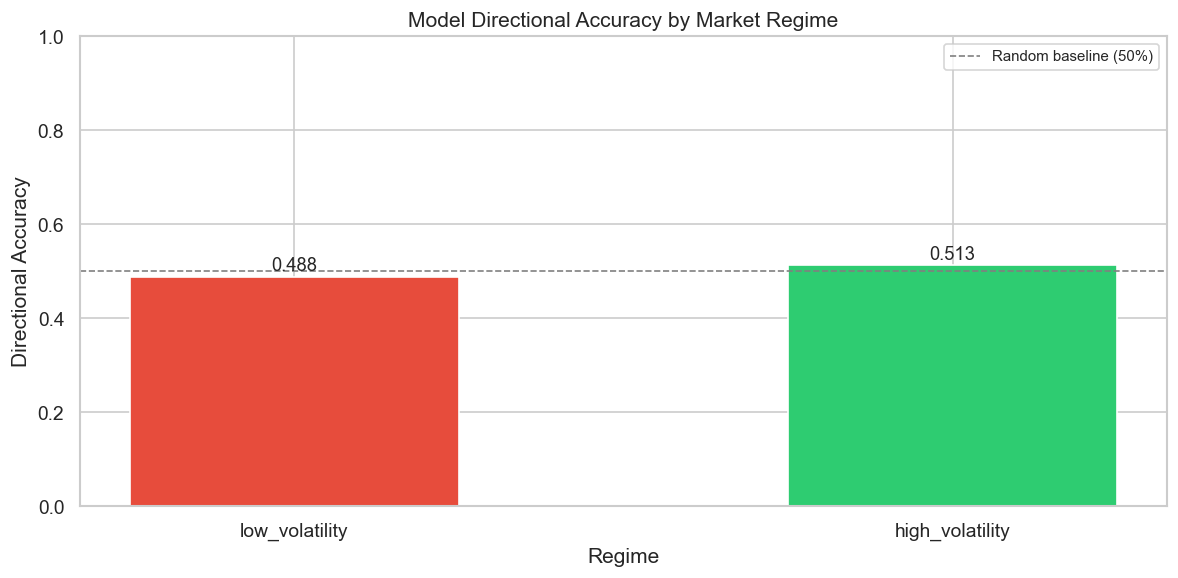

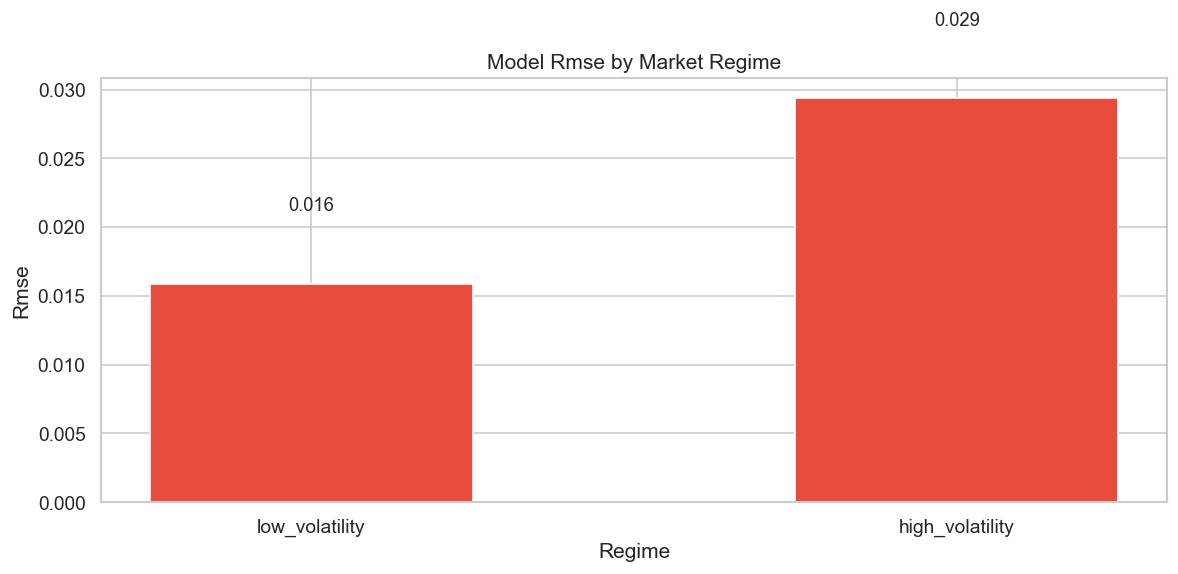

In [18]:
fig = plot_regime_performance_bar(regime_perf, metric='directional_accuracy')
plt.show()

fig = plot_regime_performance_bar(regime_perf, metric='rmse')
plt.show()

---
## 7. Feature Importance over Time

Ridge regression coefficients evolve across walk-forward folds.  
Abrupt changes in which features are most weighted are a signal of regime-driven model adaptation.

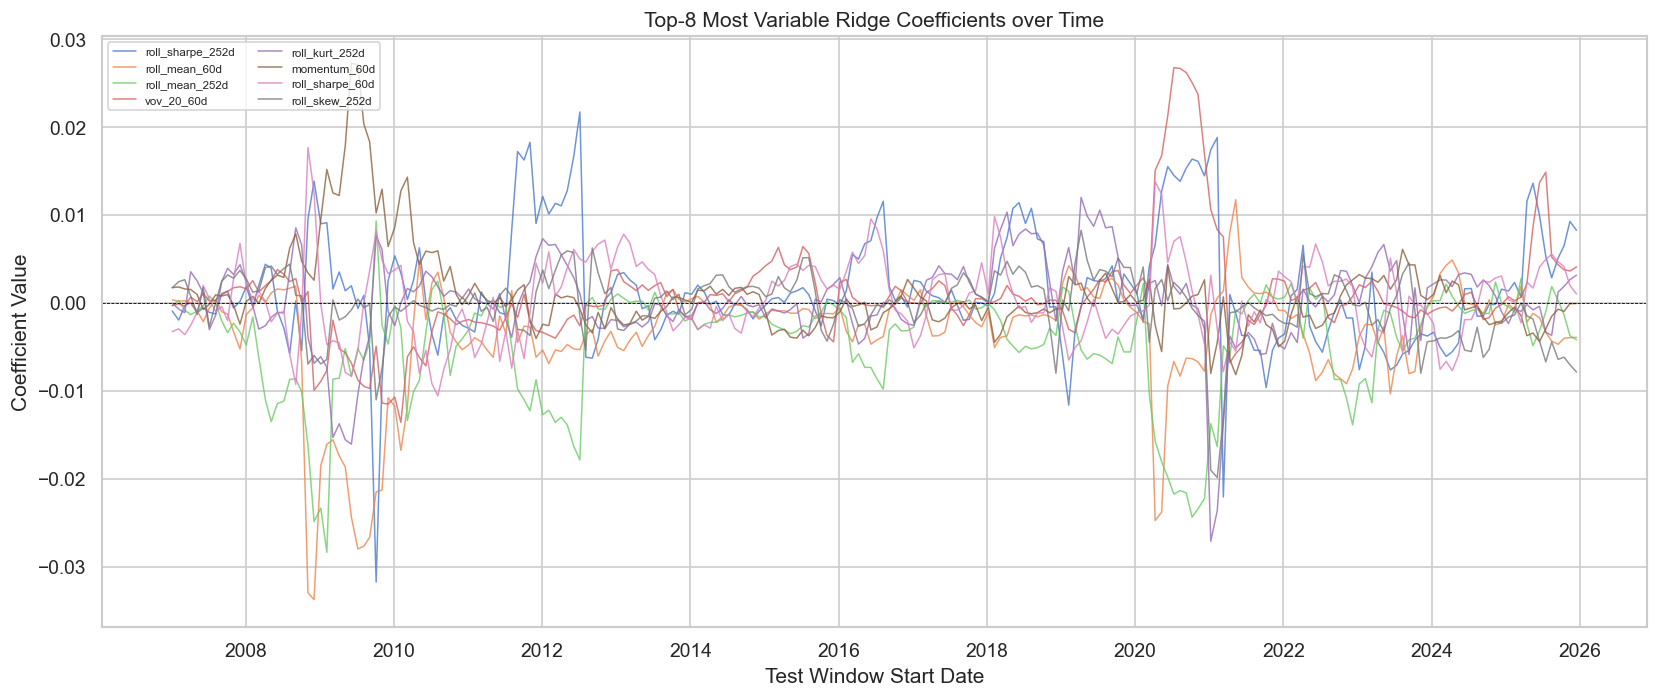


Coefficient volatility (std over time) — top features:
roll_sharpe_252d     0.006567
roll_mean_60d        0.006458
roll_mean_252d       0.006027
vov_20_60d           0.005723
roll_kurt_252d       0.004925
momentum_60d         0.004749
roll_sharpe_60d      0.004434
roll_skew_252d       0.003701
realized_vol_252d    0.003672
roll_vol_252d        0.003593


In [19]:
coef_df = feature_importance_over_time(records)

# Plot the top-8 most variable features (largest std of coefficient over time)
top_features = coef_df.std().nlargest(8).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for col in top_features:
    ax.plot(coef_df.index, coef_df[col], linewidth=0.9, alpha=0.8, label=col)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Top-8 Most Variable Ridge Coefficients over Time')
ax.set_ylabel('Coefficient Value')
ax.set_xlabel('Test Window Start Date')
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

print('\nCoefficient volatility (std over time) — top features:')
print(coef_df.std().nlargest(10).round(6).to_string())

---
## Conclusions

### Model Performance
- Ridge regression achieves **mean directional accuracy close to 50%**. This is consistent with the efficient market hypothesis: the market is hard to beat with a simple linear model.
- Performance is **noticeably worse in high-volatility regimes** (larger RMSE). The model trained in calm periods does not generalise to crisis dynamics.

### Drift–Performance Link
- **PSI spikes and RMSE spikes are co-incident** with major market events (GFC 2008, COVID 2020).
- Statistical correlation between drift metrics and RMSE provides quantitative evidence that **distribution shift explains part of the model's performance degradation**.

### Practical Implications for Model Monitoring
1. **Set PSI alert thresholds**: trigger model review when PSI > 0.10 and trigger retraining when PSI > 0.20.
2. **Monitor KS p-values** alongside PSI for robustness. Both metrics together reduce false-alarm rates.
3. **Regime-conditional retraining** (training separate models per regime) would likely improve performance.
4. **VoV and skewness spikes** are potential early-warning indicators of upcoming drift. They worth monitoring before the drift fully materialises.

---
*This project demonstrates how statistical drift detection can be integrated into a financial ML monitoring pipeline. The methods are general and apply to any deployed model operating on non-stationary financial data.*